# 2026 CTS 拖轮 AIS 赛题：任务理解、数据探索与清洗框架

这个 Notebook 的目标不是马上追求最高分，而是先建立一套可复用的分析框架：

1. 理解赛题 A / B 的标签口径。
2. 检查 AIS 数据字段、时间范围、船舶数量、缺失和异常。
3. 把经纬度转换成距离，并按官方圈层划分区域。
4. 按官方规则构造训练期 A 题和 B 题的小时级标签。
5. 总结清洗策略和 baseline 建模思路。

> 运行建议：这个训练集约 240MB，完整读取在普通电脑上通常可以接受。若内存紧张，可以先把 `RUN_FULL = False`，只跑采样理解流程。

## 0. 环境与路径

先集中定义路径、导入依赖。后续所有代码都从这里取路径，避免散落硬编码。

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Notebook 可能从项目根目录运行，也可能从 notebooks/ 目录运行。
# 数据目录也可能被移动。这里不硬编码中文目录名，而是在项目目录内递归查找 CSV。
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents, Path(r"C:\Users\mandy\hl_Documents\2026CTS")]
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "Clippings").exists() or (candidate / "PLAN.md").exists() or (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("找不到项目根目录")

def find_data_files(root: Path) -> tuple[Path, Path]:
    csv_files = [p for p in root.rglob("*.csv") if p.is_file()]
    if not csv_files:
        raise FileNotFoundError(f"在项目目录中找不到 CSV 文件: {root}")

    # 训练集是最大的 AIS 明细 CSV；验证每日船数文件很小。
    csv_files = sorted(csv_files, key=lambda p: p.stat().st_size, reverse=True)
    train_path = csv_files[0]
    val_candidates = [p for p in csv_files[1:] if p.stat().st_size < 100_000]
    if not val_candidates:
        raise FileNotFoundError("找不到验证每日船数 CSV。请确认验证集 CSV 已解压。")
    val_daily_path = val_candidates[0]
    return train_path, val_daily_path

ROOT = find_project_root(Path.cwd())
TRAIN_PATH, VAL_DAILY_PATH = find_data_files(ROOT)

RUN_FULL = True  # 如果电脑内存不够，改成 False，只读取前 20 万行做演示
SAMPLE_NROWS = 200_000

print("项目根目录:", ROOT)
print("训练集路径:", TRAIN_PATH)
print("训练集是否存在:", TRAIN_PATH.exists(), "大小MB:", round(TRAIN_PATH.stat().st_size / 1024 / 1024, 2))
print("验证每日船数路径:", VAL_DAILY_PATH)
print("验证每日船数是否存在:", VAL_DAILY_PATH.exists(), "大小B:", VAL_DAILY_PATH.stat().st_size)

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"训练集不存在: {TRAIN_PATH}")
if not VAL_DAILY_PATH.exists():
    raise FileNotFoundError(f"验证每日船数文件不存在: {VAL_DAILY_PATH}")

项目根目录: C:\Users\mandy\hl_Documents\2026CTS
训练集路径: C:\Users\mandy\hl_Documents\2026CTS\notebooks\训练集_20180101-0124_拖轮AIS\训练集_20180101-0124_拖轮AIS.csv
训练集是否存在: True 大小MB: 229.17
验证每日船数路径: C:\Users\mandy\hl_Documents\2026CTS\notebooks\验证集_20180125-0131_每日拖轮数量\验证集_20180125-0131_每日拖轮数量.csv
验证每日船数是否存在: True 大小B: 116


## 1. 先用赛题规则定义我们要预测什么

### 赛题 A：活跃拖轮数量

每个小时、每个圈层，统计满足下面条件的拖轮数：

- `2 <= SOG <= 10`
- 同一艘船在同一小时、同一圈层内至少有 3 条 AIS 记录
- 如果同一艘船同一小时在多个圈层都满足条件，则在多个圈层分别计数

### 赛题 B：圈层迁移量

每艘船每小时先确定一个“代表圈层”：

- 取 AIS 点数最多的圈层
- 如果多个圈层点数并列，取最后出现时间更晚的圈层
- 不要求 `SOG` 在 2 到 10，也不要求至少 3 条活跃记录

然后比较相邻小时：如果某船在小时 `t` 的代表圈层为 A，在小时 `t+1` 的代表圈层为 B，且 A != B，则记一次 `A -> B` 迁移。

这意味着本题的第一步不是建模，而是把原始 AIS 数据稳定地聚合成训练标签。

## 2. 文件体检：大小、列名、前几行

这一步只读少量数据，快速判断：

- CSV 是否能正常读取
- 字段是否符合说明
- 时间格式是否标准
- `mmsi` 是否需要按字符串处理

注意：`mmsi` 有前导 0，例如 `000001119`，必须按字符串读，否则会丢失前导 0。

In [2]:
file_size_mb = TRAIN_PATH.stat().st_size / 1024 / 1024
print(f"训练集大小: {file_size_mb:.1f} MB")

head = pd.read_csv(TRAIN_PATH, nrows=8, dtype={"mmsi": "string"})
display(head)
print(head.dtypes)

训练集大小: 229.2 MB


,mmsi,x,y,cog,true_heading,sog,rot,time,source_dataset,ship_type
0,000001119,117.789772,38.975652,295.200012,21,0.0,0.000000,2018-01-01 02:41:47,china_coastal,Tug
1,000003019,117.790202,38.968270,317.000000,209,2.1,720.003235,2018-01-01 03:41:29,china_coastal,Tug
2,000001119,117.777335,38.999128,154.100006,155,6.9,0.000000,2018-01-01 07:51:33,china_coastal,Tug
3,000003080,117.774093,39.006663,172.600006,260,0.0,0.000000,2018-01-01 07:57:01,china_coastal,Tug
4,000001051,117.789400,38.975533,230.100006,179,0.0,0.000000,2018-01-01 08:15:31,china_coastal,Tug
5,000001129,117.788517,38.973267,277.600006,215,0.0,0.000000,2018-01-01 08:30:53,china_coastal,Tug
6,000002127,117.698143,39.000283,282.100006,511,0.0,-731.386475,2018-01-01 14:10:58,china_coastal,Anchor Handling Tug Supply
7,000001071,117.788635,38.975175,279.100006,511,0.1,-731.386475,2018-01-01 14:51:43,china_coastal,Tug


mmsi              string[python]
x                        float64
y                        float64
cog                      float64
true_heading               int64
sog                      float64
rot                      float64
time                      object
source_dataset            object
ship_type                 object
dtype: object


## 3. 读取数据：全量或采样

为了后续分析方便，我们只读取当前任务需要的字段。

字段理解：

- `mmsi`：船舶标识，按字符串处理
- `x`：经度
- `y`：纬度
- `cog`：对地航向，通常 0-360
- `true_heading`：真航向，AIS 中 `511` 常表示不可用
- `sog`：对地航速，单位节
- `rot`：转向率，可能缺失或出现极端编码值
- `time`：秒级时间戳
- `ship_type`：船舶类型，本数据以拖轮相关类型为主，但也混入少量其他类型

In [3]:
usecols = ["mmsi", "x", "y", "cog", "true_heading", "sog", "rot", "time", "source_dataset", "ship_type"]
dtypes = {
    "mmsi": "string",
    "x": "float64",
    "y": "float64",
    "cog": "float32",
    "true_heading": "float32",
    "sog": "float32",
    "rot": "float32",
    "source_dataset": "category",
    "ship_type": "category",
}

read_kwargs = dict(usecols=usecols, dtype=dtypes, parse_dates=["time"])
if not RUN_FULL:
    read_kwargs["nrows"] = SAMPLE_NROWS

df = pd.read_csv(TRAIN_PATH, **read_kwargs)

print("读取行数:", len(df))
print("内存占用 MB:", round(df.memory_usage(deep=True).sum() / 1024 / 1024, 2))
display(df.head())

读取行数: 2039846
内存占用 MB: 210.1


,mmsi,x,y,cog,true_heading,sog,rot,time,source_dataset,ship_type
0,000001119,117.789772,38.975652,295.200012,21.0,0.0,0.000000,2018-01-01 02:41:47,china_coastal,Tug
1,000003019,117.790202,38.968270,317.000000,209.0,2.1,720.003235,2018-01-01 03:41:29,china_coastal,Tug
2,000001119,117.777335,38.999128,154.100006,155.0,6.9,0.000000,2018-01-01 07:51:33,china_coastal,Tug
3,000003080,117.774093,39.006663,172.600006,260.0,0.0,0.000000,2018-01-01 07:57:01,china_coastal,Tug
4,000001051,117.789400,38.975533,230.100006,179.0,0.0,0.000000,2018-01-01 08:15:31,china_coastal,Tug


## 4. 基础数据画像

先回答几个最基本的问题：

- 训练集覆盖哪几天？是否完整到小时？
- 有多少艘船？每天大约出现多少艘？
- 是否有缺失？
- 速度、转向率、坐标范围是否有异常？

In [4]:
def basic_profile(data: pd.DataFrame) -> None:
    print("行数:", len(data))
    print("列数:", data.shape[1])
    print("时间范围:", data["time"].min(), "->", data["time"].max())
    print("唯一 MMSI:", data["mmsi"].nunique())
    print("唯一日期数:", data["time"].dt.date.nunique())
    print("\n缺失值:")
    display(data.isna().sum().to_frame("missing"))
    print("\n船型分布 Top 15:")
    display(data["ship_type"].value_counts(dropna=False).head(15).to_frame("rows"))

basic_profile(df)

行数: 2039846
列数: 10
时间范围: 2018-01-01 00:00:00 -> 2018-01-24 23:59:59
唯一 MMSI: 109


唯一日期数: 24

缺失值:


,missing
mmsi,0
x,0
y,0
cog,0
true_heading,354
sog,0
rot,11542
time,0
source_dataset,0
ship_type,0



船型分布 Top 15:


,rows
ship_type,
Tug,1759931
Anchor Handling Tug Supply,155283
Offshore Tug/Supply Ship,75916
Towing,12854
Salvage Ship,11686
Pilot Vessel,8547
Well Stimulation Vessel,7180
Towing (large tow),6210
Container Ship (Fully Cellular),1143


In [5]:
num_cols = ["x", "y", "cog", "true_heading", "sog", "rot"]
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
x,2039846.0,117.812037,0.104608,117.568373,117.683997,117.721417,117.769553,117.788837,117.791591,118.052452,118.219000,118.268095
y,2039846.0,38.965895,0.035061,38.715200,38.765437,38.896084,38.967670,38.974597,38.981390,38.995620,39.012917,39.208853
cog,2039846.0,204.783676,103.047714,0.000000,2.400000,20.400000,114.099998,225.800003,290.600006,343.399994,356.899994,360.000000
true_heading,2039492.0,195.424133,133.011993,0.000000,8.000000,22.000000,88.000000,194.000000,285.000000,511.000000,511.000000,511.000000
sog,2039846.0,2.288365,3.889834,0.000000,0.000000,0.000000,0.000000,0.100000,3.400000,10.400000,12.100000,102.300003
rot,2028304.0,-42.673534,351.989014,-731.386475,-731.386475,-731.386475,0.000000,0.000000,0.000000,720.003235,720.003235,720.003235


### 观察要点

通常这里会看到：

- `sog` 大量为 0 或接近 0，说明拖轮有大量停泊、等待或低速状态。
- `sog` 可能存在非常大的离群值，A 题规则会筛掉 `>10` 的点，但做 B 题或轨迹清洗时仍要注意。
- `true_heading = 511` 在 AIS 里通常表示不可用，不应当直接当作正常角度。
- `rot` 可能缺失，也可能有 AIS 编码边界值，A/B 官方口径其实不依赖它，先不要过度清洗。

## 5. 时间维度理解

AIS 是不规则采样数据。说明里说采样间隔中位数约 10 秒，但真实数据会有断点、缺测、停发。

我们先看：

- 每天记录数
- 每天出现船数
- 每小时记录数
- 单船相邻 AIS 的时间间隔分布

In [6]:
df["date"] = df["time"].dt.date
df["hour"] = df["time"].dt.floor("h")
df["hour_of_day"] = df["time"].dt.hour
df["dayofweek"] = df["time"].dt.dayofweek

daily = df.groupby("date").agg(
    rows=("mmsi", "size"),
    vessels=("mmsi", "nunique"),
    mean_sog=("sog", "mean"),
    p95_sog=("sog", lambda s: s.quantile(0.95)),
)
display(daily)

,rows,vessels,mean_sog,p95_sog
date,,,,
2018-01-01,113491,49,2.555114,10.6
2018-01-02,149794,53,2.640646,10.6
2018-01-03,141403,58,2.424135,10.6
2018-01-04,104676,55,2.613117,10.8
2018-01-05,130152,57,2.397811,10.6
2018-01-06,134287,61,2.357713,10.6
2018-01-07,101437,60,2.482475,10.4
2018-01-08,140953,56,1.702117,10.0
2018-01-09,81419,54,2.313173,10.3


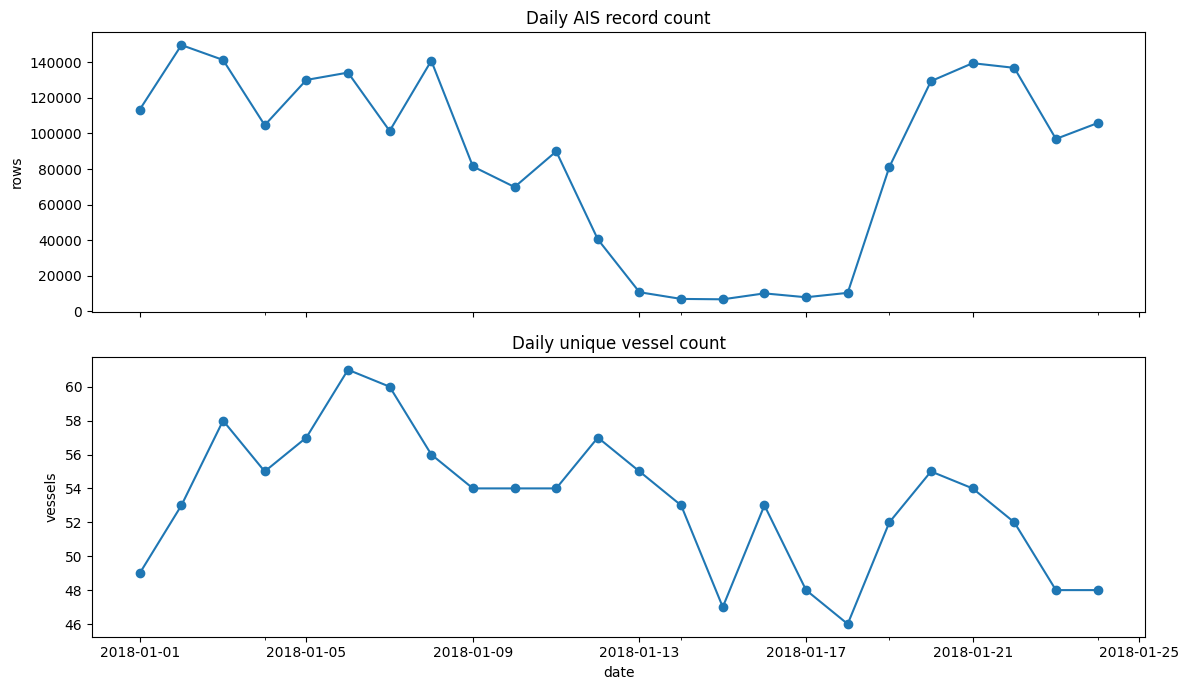

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
daily["rows"].plot(ax=axes[0], marker="o", title="Daily AIS record count")
daily["vessels"].plot(ax=axes[1], marker="o", title="Daily unique vessel count")
axes[0].set_ylabel("rows")
axes[1].set_ylabel("vessels")
plt.tight_layout()
plt.show()

count    2.028659e+06
mean     4.238919e+01
std      1.178519e+02
min      1.000000e+00
10%      4.000000e+00
25%      9.000000e+00
50%      1.000000e+01
75%      2.000000e+01
90%      1.460000e+02
95%      1.810000e+02
99%      5.070000e+02
max      3.600000e+03
Name: time, dtype: float64


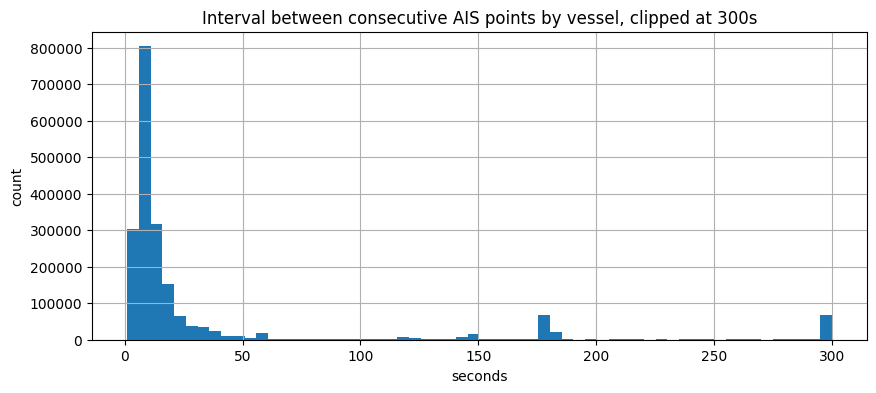

In [8]:
# 单船相邻记录时间间隔。数据已按 mmsi + time 排序后计算。
df_sorted = df.sort_values(["mmsi", "time"])
dt = df_sorted.groupby("mmsi")["time"].diff().dt.total_seconds()
valid_dt = dt[(dt > 0) & (dt <= 3600)]
print(valid_dt.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

plt.figure(figsize=(10, 4))
valid_dt.clip(upper=300).hist(bins=60)
plt.title("Interval between consecutive AIS points by vessel, clipped at 300s")
plt.xlabel("seconds")
plt.ylabel("count")
plt.show()

## 6. 空间圈层计算

官方圈层以 `117.79E, 38.97N` 为中心，按半径 3km、10km、30km 切分。

这里用近似等距投影计算距离：

- 纬度每 1 度约 111.32 km
- 经度每 1 度约 `111.32 * cos(latitude)` km

港区范围不大，这个近似足够稳定；如果要更严谨，可以换成 haversine 公式。

In [9]:
CENTER_LON = 117.79
CENTER_LAT = 38.97
KM_PER_LAT = 111.32
KM_PER_LON = 111.32 * math.cos(math.radians(CENTER_LAT))

REGION_ORDER = ["core", "near", "outer"]
REGION_CN = {
    "core": "核心区(0-3km)",
    "near": "近港区(3-10km)",
    "outer": "外围区(10-30km)",
    "outside": "30km外",
}

def add_distance_and_region(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    dx = (data["x"] - CENTER_LON) * KM_PER_LON
    dy = (data["y"] - CENTER_LAT) * KM_PER_LAT
    data["dist_km"] = np.sqrt(dx * dx + dy * dy)
    data["region"] = np.select(
        [data["dist_km"] < 3, data["dist_km"].between(3, 10, inclusive="left"), data["dist_km"].between(10, 30, inclusive="left")],
        ["core", "near", "outer"],
        default="outside",
    )
    data["region"] = pd.Categorical(data["region"], categories=["core", "near", "outer", "outside"], ordered=True)
    return data

df = add_distance_and_region(df)

display(df[["x", "y", "dist_km", "region"]].head())
print(df["region"].value_counts())
print("\n各圈层唯一船数:")
display(df.groupby("region", observed=True)["mmsi"].nunique().to_frame("unique_vessels"))

,x,y,dist_km,region
0,117.789772,38.975652,0.629454,core
1,117.790202,38.968270,0.193373,core
2,117.777335,38.999128,3.422828,near
3,117.774093,39.006663,4.307298,near
4,117.789400,38.975533,0.618156,core


region
core       1132351
near        597639
outer       238836
outside      71020
Name: count, dtype: int64

各圈层唯一船数:


,unique_vessels
region,
core,72
near,92
outer,89
outside,75


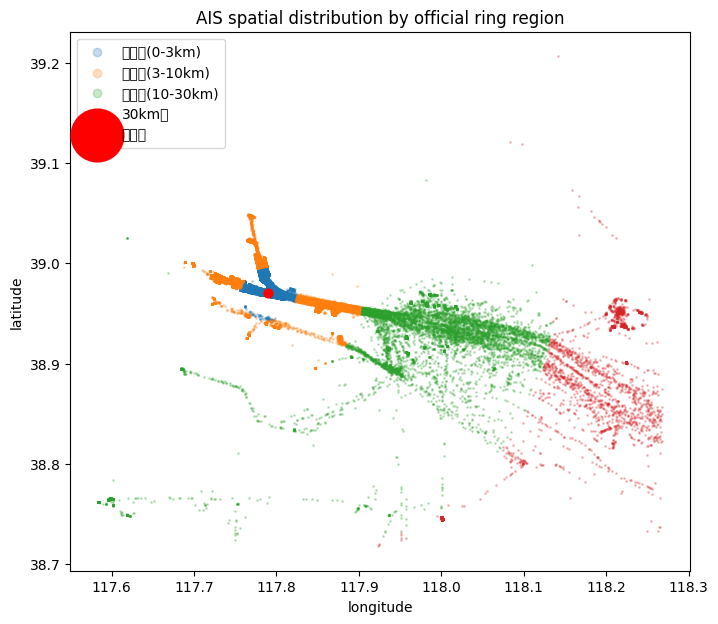

In [10]:
plt.figure(figsize=(8, 7))
plot_sample = df.sample(min(len(df), 80_000), random_state=42)
for region in ["core", "near", "outer", "outside"]:
    part = plot_sample[plot_sample["region"] == region]
    plt.scatter(part["x"], part["y"], s=1, alpha=0.25, label=REGION_CN[region])
plt.scatter([CENTER_LON], [CENTER_LAT], c="red", s=40, label="中心点")
plt.title("AIS spatial distribution by official ring region")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.legend(markerscale=6)
plt.show()

## 7. 清洗策略：先区分“标签口径清洗”和“建模特征清洗”

这是很关键的原则。

### 7.1 生成官方标签时，尽量只做必要清洗

A/B 标签应该严格贴近官方口径，避免因为过度清洗导致训练标签和评测标签口径不一致。

建议：

- 保留全部 `mmsi`，包括非纯 `Tug` 的拖轮相关类型。
- A 题只按规则筛 `2 <= sog <= 10`、同船同小时同区域记录数 >= 3。
- B 题不筛 `sog`，只排除 `outside`，按众数区域和最后时间打破平局。
- 不用 `rot`、`cog`、`true_heading` 参与标签构造。

### 7.2 做模型特征时，可以额外清洗或派生

例如：

- `true_heading == 511` 视为缺失。
- `cog` 不在 `[0, 360)` 的值视为异常。
- `sog > 30` 或明显不合理速度可作为异常点计数特征，而不是直接删掉。
- 坐标在 30km 外的点对 A/B 官方圈层输出没有直接贡献，但可以作为“离港活动”或数据质量特征。
- 重复点可以统计，也可以在特征工程中去重；但标签构造是否去重需要谨慎。

In [11]:
def add_quality_flags(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["flag_sog_active"] = data["sog"].between(2, 10, inclusive="both")
    data["flag_sog_extreme"] = data["sog"] > 30
    data["flag_heading_invalid"] = data["true_heading"].isna() | (data["true_heading"] == 511) | ~data["true_heading"].between(0, 360, inclusive="left")
    data["flag_cog_invalid"] = data["cog"].isna() | ~data["cog"].between(0, 360, inclusive="left")
    data["flag_rot_missing"] = data["rot"].isna()
    data["flag_outside_30km"] = data["region"].eq("outside")
    return data

df = add_quality_flags(df)

quality_summary = df[[
    "flag_sog_active", "flag_sog_extreme", "flag_heading_invalid", "flag_cog_invalid", "flag_rot_missing", "flag_outside_30km"
]].mean().sort_values(ascending=False).to_frame("ratio")
display(quality_summary)

,ratio
flag_sog_active,0.217795
flag_heading_invalid,0.074465
flag_outside_30km,0.034816
flag_rot_missing,0.005658
flag_cog_invalid,0.000136
flag_sog_extreme,0.000132


## 8. 构造赛题 A 训练标签

实现步骤：

1. 保留官方三个圈层内的数据，排除 `outside`。
2. 保留 `2 <= sog <= 10` 的活跃 AIS 点。
3. 按 `hour + region + mmsi` 统计 AIS 点数。
4. 只保留点数 `>= 3` 的船。
5. 再按 `hour + region` 统计船数，得到 A 题标签。

输出粒度：每个小时 3 个圈层。为了训练模型，缺失组合应该补 0。

In [12]:
def make_a_labels(data: pd.DataFrame) -> pd.DataFrame:
    active = data[
        data["region"].isin(REGION_ORDER)
        & data["sog"].between(2, 10, inclusive="both")
    ].copy()

    ship_region_counts = (
        active.groupby(["hour", "region", "mmsi"], observed=True)
        .size()
        .rename("ais_points")
        .reset_index()
    )
    qualified = ship_region_counts[ship_region_counts["ais_points"] >= 3]

    labels = (
        qualified.groupby(["hour", "region"], observed=True)["mmsi"]
        .nunique()
        .rename("active_tug_count")
        .reset_index()
    )

    # 补齐所有 hour-region 组合，没有活跃船则为 0
    hours = pd.date_range(data["hour"].min(), data["hour"].max(), freq="h")
    full_index = pd.MultiIndex.from_product([hours, REGION_ORDER], names=["hour", "region"])
    labels = (
        labels.set_index(["hour", "region"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )
    labels["region"] = pd.Categorical(labels["region"], categories=REGION_ORDER, ordered=True)
    return labels

a_labels = make_a_labels(df)
print(a_labels.shape)
display(a_labels.head(12))
display(a_labels.groupby("region", observed=True)["active_tug_count"].describe())

(1728, 3)


,hour,region,active_tug_count
0,2018-01-01 00:00:00,core,2
1,2018-01-01 00:00:00,near,0
2,2018-01-01 00:00:00,outer,1
3,2018-01-01 01:00:00,core,0
4,2018-01-01 01:00:00,near,2
5,2018-01-01 01:00:00,outer,1
6,2018-01-01 02:00:00,core,6
7,2018-01-01 02:00:00,near,2
8,2018-01-01 02:00:00,outer,0
9,2018-01-01 03:00:00,core,13


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
core,576.0,5.918403,4.311595,0.0,2.0,6.0,9.0,17.0
near,576.0,3.769097,3.074238,0.0,1.0,3.0,6.0,14.0
outer,576.0,1.758681,1.561191,0.0,1.0,1.0,3.0,9.0


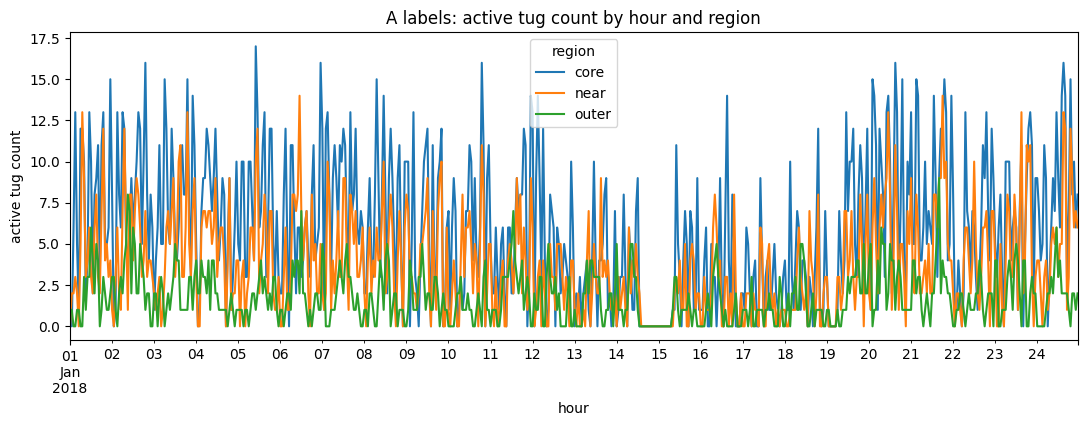

In [13]:
a_pivot = a_labels.pivot(index="hour", columns="region", values="active_tug_count")
ax = a_pivot.plot(figsize=(13, 4), title="A labels: active tug count by hour and region")
ax.set_ylabel("active tug count")
plt.show()

## 9. 构造赛题 B 训练标签

实现步骤：

1. 保留官方三个圈层内的数据，排除 `outside`。
2. 对每个 `mmsi + hour + region`，计算：
   - 该区域 AIS 点数 `points`
   - 该区域最后出现时间 `last_time`
3. 对每个 `mmsi + hour` 排序：`points` 多的优先，`last_time` 晚的优先。
4. 取第一名作为该船该小时的代表圈层。
5. 同一艘船按时间排序，比较相邻小时代表圈层。
6. 只有连续小时才计算迁移，例如 `10:00 -> 11:00`；中间缺小时则不计。
7. 补齐所有 `hour + source + target` 组合，不发生迁移则为 0。

B 题只考虑 6 个有向迁移：核心到近港、核心到外围、近港到核心、近港到外围、外围到核心、外围到近港。

In [14]:
def make_b_labels(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    in_region = data[data["region"].isin(REGION_ORDER)].copy()

    agg = (
        in_region.groupby(["mmsi", "hour", "region"], observed=True)
        .agg(points=("time", "size"), last_time=("time", "max"))
        .reset_index()
    )

    representative = (
        agg.sort_values(["mmsi", "hour", "points", "last_time"], ascending=[True, True, False, False])
        .drop_duplicates(["mmsi", "hour"], keep="first")
        .sort_values(["mmsi", "hour"])
        .rename(columns={"region": "region_rep"})
    )

    representative["next_hour"] = representative.groupby("mmsi")["hour"].shift(-1)
    representative["target_region"] = representative.groupby("mmsi")["region_rep"].shift(-1)

    moved = representative[
        (representative["next_hour"] == representative["hour"] + pd.Timedelta(hours=1))
        & (representative["region_rep"].astype(str) != representative["target_region"].astype(str))
    ].copy()

    labels = (
        moved.groupby(["hour", "region_rep", "target_region"], observed=True)["mmsi"]
        .nunique()
        .rename("migration_count")
        .reset_index()
        .rename(columns={"region_rep": "source_region"})
    )

    hours = pd.date_range(data["hour"].min(), data["hour"].max(), freq="h")
    pairs = [(s, t) for s in REGION_ORDER for t in REGION_ORDER if s != t]
    full_index = pd.MultiIndex.from_tuples(
        [(h, s, t) for h in hours for s, t in pairs],
        names=["hour", "source_region", "target_region"],
    )
    labels = (
        labels.set_index(["hour", "source_region", "target_region"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )
    return labels, representative

b_labels, representative_region = make_b_labels(df)
print(b_labels.shape)
display(b_labels.head(12))
display(b_labels.groupby(["source_region", "target_region"])["migration_count"].describe())

(3456, 4)


,hour,source_region,target_region,migration_count
0,2018-01-01 00:00:00,core,near,0
1,2018-01-01 00:00:00,core,outer,0
2,2018-01-01 00:00:00,near,core,0
3,2018-01-01 00:00:00,near,outer,0
4,2018-01-01 00:00:00,outer,core,0
5,2018-01-01 00:00:00,outer,near,0
6,2018-01-01 01:00:00,core,near,0
7,2018-01-01 01:00:00,core,outer,0
8,2018-01-01 01:00:00,near,core,0
9,2018-01-01 01:00:00,near,outer,0


count      mean       std  min  25%  50%  75%  max
source_region target_region                                                    
core          near           576.0  1.083333  1.470877  0.0  0.0  0.0  2.0  9.0
              outer          576.0  0.215278  0.536179  0.0  0.0  0.0  0.0  3.0
near          core           576.0  1.098958  1.366277  0.0  0.0  1.0  2.0  9.0
              outer          576.0  0.342014  0.745565  0.0  0.0  0.0  0.0  6.0
outer         core           576.0  0.185764  0.477536  0.0  0.0  0.0  0.0  3.0
              near           576.0  0.390625  0.749619  0.0  0.0  0.0  1.0  5.0

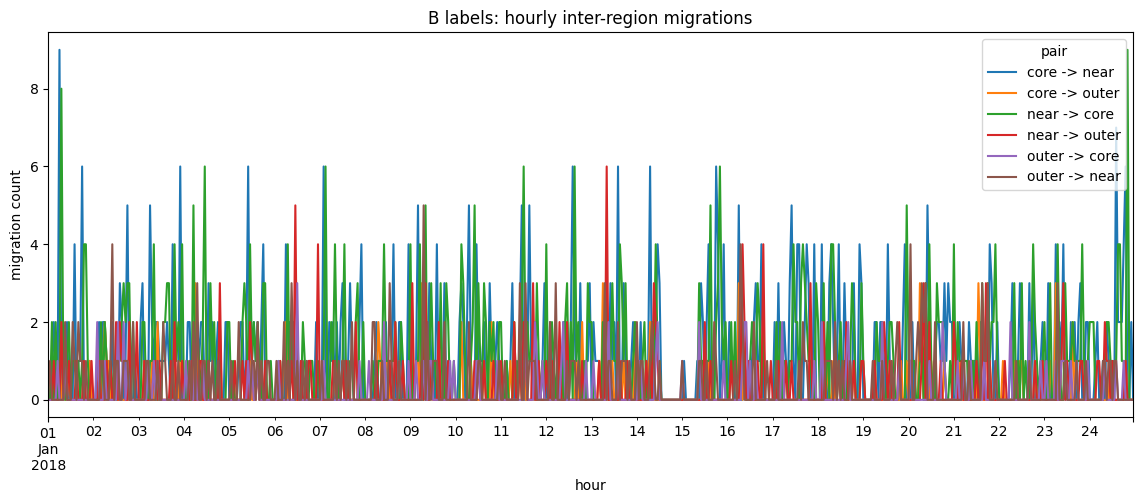

In [15]:
b_pivot = b_labels.copy()
b_pivot["pair"] = b_pivot["source_region"].astype(str) + " -> " + b_pivot["target_region"].astype(str)
b_wide = b_pivot.pivot(index="hour", columns="pair", values="migration_count")
ax = b_wide.plot(figsize=(14, 5), title="B labels: hourly inter-region migrations")
ax.set_ylabel("migration count")
plt.show()

## 10. 用验证集每日船数理解未来 7 天规模

验证集只给了每天出现过的唯一船舶总数，不给 AIS 明细。它不能直接推出 A/B 标签，但可以帮助判断未来每天整体规模。

一种简单做法：

- 从训练集计算每天唯一船数。
- 建模时把验证期每日船数作为外生特征。
- 对按小时预测结果做每日规模校准，例如某天验证船数低于训练均值，则 A/B 的预测也可以适当收缩。

In [16]:
val_daily = pd.read_csv(VAL_DAILY_PATH, parse_dates=["date"])
train_daily_vessels = df.groupby("date")["mmsi"].nunique().rename("train_vessel_count").reset_index()
train_daily_vessels["date"] = pd.to_datetime(train_daily_vessels["date"])

print("训练期每日唯一船数:")
display(train_daily_vessels)
print("验证期每日唯一船数:")
display(val_daily)

print("训练期每日船数统计:")
display(train_daily_vessels["train_vessel_count"].describe().to_frame().T)

训练期每日唯一船数:


,date,train_vessel_count
0,2018-01-01,49
1,2018-01-02,53
2,2018-01-03,58
3,2018-01-04,55
4,2018-01-05,57
5,2018-01-06,61
6,2018-01-07,60
7,2018-01-08,56
8,2018-01-09,54
9,2018-01-10,54


验证期每日唯一船数:


,date,vessel_count
0,2018-01-25,47
1,2018-01-26,51
2,2018-01-27,55
3,2018-01-28,52
4,2018-01-29,50
5,2018-01-30,50
6,2018-01-31,48


训练期每日船数统计:


,count,mean,std,min,25%,50%,75%,max
train_vessel_count,24.0,53.291667,4.016046,46.0,51.25,54.0,55.25,61.0


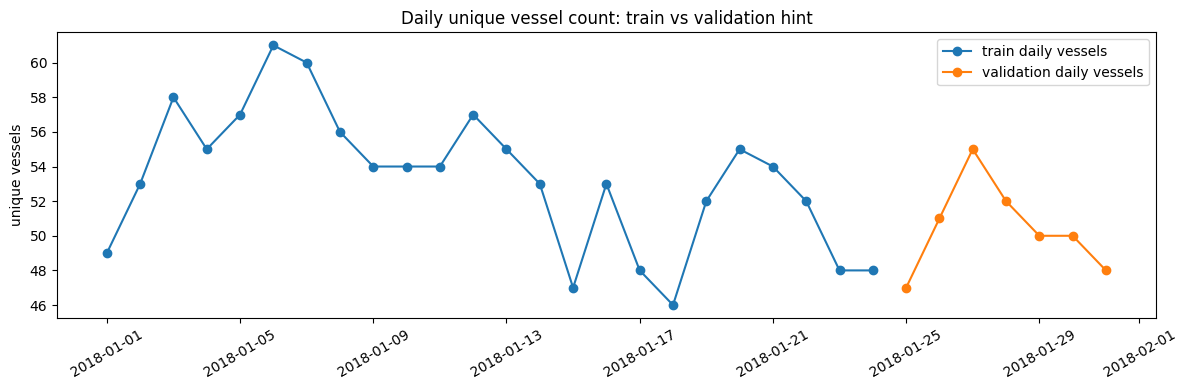

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(train_daily_vessels["date"], train_daily_vessels["train_vessel_count"], marker="o", label="train daily vessels")
plt.plot(val_daily["date"], val_daily["vessel_count"], marker="o", label="validation daily vessels")
plt.title("Daily unique vessel count: train vs validation hint")
plt.ylabel("unique vessels")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 11. 特征工程框架

到这里，我们已经把原始 AIS 转成了两个训练表：

- `a_labels`：每小时、每圈层的活跃拖轮数
- `b_labels`：每小时、每个有向圈层对的迁移量

后续建模可以把它们看作小规模时间序列预测问题。

推荐先做下面这些特征：

### 时间特征

- `hour_of_day`
- `dayofweek`
- 是否周末
- 是否工作日
- 距离训练结束的天数

### 历史统计特征

- 同一圈层/迁移对的过去 1 小时、2 小时、24 小时 lag
- 过去 3 小时、6 小时、24 小时滚动均值
- 同小时-of-day 历史均值
- 同星期几 + 同小时的历史均值

### 验证每日船数特征

- 当天唯一船数
- 当天船数 / 训练期平均每日船数
- 当天船数 / 过去 7 天平均每日船数

### 质量和行为特征

如果要从原始 AIS 构造额外特征，可以按小时统计：

- 每小时 AIS 总点数
- 每小时唯一船数
- 每小时各圈层点数
- 每小时 `SOG` 均值、分位数
- 每小时异常速度点比例
- 每小时 30km 外点比例

不过验证期没有 AIS 明细，所以这些特征只能用于训练期回测或构造周期规律，不能直接用于最终验证期，除非题方后续提供验证 AIS。

In [18]:
def add_time_features(label_df: pd.DataFrame, date_vessel_hint: pd.DataFrame | None = None) -> pd.DataFrame:
    out = label_df.copy()
    out["date"] = out["hour"].dt.normalize()
    out["hour_of_day"] = out["hour"].dt.hour
    out["dayofweek"] = out["hour"].dt.dayofweek
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)

    if date_vessel_hint is not None:
        hint = date_vessel_hint.copy()
        hint["date"] = pd.to_datetime(hint["date"])
        if "vessel_count" not in hint.columns:
            hint = hint.rename(columns={"train_vessel_count": "vessel_count"})
        out = out.merge(hint[["date", "vessel_count"]], on="date", how="left")
    return out

a_model_frame = add_time_features(a_labels, train_daily_vessels.rename(columns={"train_vessel_count": "vessel_count"}))
b_model_frame = add_time_features(b_labels, train_daily_vessels.rename(columns={"train_vessel_count": "vessel_count"}))

display(a_model_frame.head())
display(b_model_frame.head())

,hour,region,active_tug_count,date,hour_of_day,dayofweek,is_weekend,vessel_count
0,2018-01-01 00:00:00,core,2,2018-01-01,0,0,0,49
1,2018-01-01 00:00:00,near,0,2018-01-01,0,0,0,49
2,2018-01-01 00:00:00,outer,1,2018-01-01,0,0,0,49
3,2018-01-01 01:00:00,core,0,2018-01-01,1,0,0,49
4,2018-01-01 01:00:00,near,2,2018-01-01,1,0,0,49


,hour,source_region,target_region,migration_count,date,hour_of_day,dayofweek,is_weekend,vessel_count
0,2018-01-01,core,near,0,2018-01-01,0,0,0,49
1,2018-01-01,core,outer,0,2018-01-01,0,0,0,49
2,2018-01-01,near,core,0,2018-01-01,0,0,0,49
3,2018-01-01,near,outer,0,2018-01-01,0,0,0,49
4,2018-01-01,outer,core,0,2018-01-01,0,0,0,49


## 12. 一个简单但强的 baseline 思路

在正式上复杂模型前，建议先建立 baseline。原因：

- 赛题输出维度很小，只有 7 天 * 24 小时 * 3 个区域，以及 7 天 * 24 小时 * 6 个迁移方向。
- 训练期只有 24 天，复杂模型容易过拟合。
- 时间周期规律和每日船数规模约束可能已经很有用。

### Baseline 1：小时-of-day 均值

例如 A 题：预测 1 月 25 日 08:00 核心区，就取训练期所有 08:00 核心区的平均活跃船数。

### Baseline 2：星期几 + 小时均值

如果训练期样本够，可以用同星期几、同小时的均值。但 24 天只有 3-4 个同星期样本，方差会大。

### Baseline 3：混合均值

用加权方式混合：

- 70%：同小时均值
- 30%：同星期几 + 同小时均值

### Baseline 4：每日船数校准

如果验证某天每日船数比训练平均低 5%，则当天 A/B 预测可以乘以一个接近 0.95 的系数。这个系数不一定 1:1，可以通过训练期回测调。

In [19]:
def make_future_grid_a(start="2018-01-25", end="2018-01-31") -> pd.DataFrame:
    hours = pd.date_range(start, pd.Timestamp(end) + pd.Timedelta(hours=23), freq="h")
    return pd.MultiIndex.from_product([hours, REGION_ORDER], names=["hour", "region"]).to_frame(index=False)

def make_future_grid_b(start="2018-01-25", end="2018-01-31") -> pd.DataFrame:
    hours = pd.date_range(start, pd.Timestamp(end) + pd.Timedelta(hours=23), freq="h")
    pairs = [(s, t) for s in REGION_ORDER for t in REGION_ORDER if s != t]
    return pd.MultiIndex.from_tuples(
        [(h, s, t) for h in hours for s, t in pairs],
        names=["hour", "source_region", "target_region"],
    ).to_frame(index=False)

future_a = add_time_features(make_future_grid_a(), val_daily)
future_b = add_time_features(make_future_grid_b(), val_daily)

display(future_a.head())
display(future_b.head())
print("A future rows:", len(future_a))
print("B future rows:", len(future_b))

,hour,region,date,hour_of_day,dayofweek,is_weekend,vessel_count
0,2018-01-25 00:00:00,core,2018-01-25,0,3,0,47
1,2018-01-25 00:00:00,near,2018-01-25,0,3,0,47
2,2018-01-25 00:00:00,outer,2018-01-25,0,3,0,47
3,2018-01-25 01:00:00,core,2018-01-25,1,3,0,47
4,2018-01-25 01:00:00,near,2018-01-25,1,3,0,47


,hour,source_region,target_region,date,hour_of_day,dayofweek,is_weekend,vessel_count
0,2018-01-25,core,near,2018-01-25,0,3,0,47
1,2018-01-25,core,outer,2018-01-25,0,3,0,47
2,2018-01-25,near,core,2018-01-25,0,3,0,47
3,2018-01-25,near,outer,2018-01-25,0,3,0,47
4,2018-01-25,outer,core,2018-01-25,0,3,0,47


A future rows: 504
B future rows: 1008


In [20]:
def predict_by_hour_mean_a(train_frame: pd.DataFrame, future_frame: pd.DataFrame) -> pd.DataFrame:
    hourly_mean = (
        train_frame.groupby(["region", "hour_of_day"], observed=True)["active_tug_count"]
        .mean()
        .rename("pred")
        .reset_index()
    )
    pred = future_frame.merge(hourly_mean, on=["region", "hour_of_day"], how="left")
    pred["pred"] = pred["pred"].fillna(train_frame["active_tug_count"].mean())
    return pred

def predict_by_hour_mean_b(train_frame: pd.DataFrame, future_frame: pd.DataFrame) -> pd.DataFrame:
    hourly_mean = (
        train_frame.groupby(["source_region", "target_region", "hour_of_day"], observed=True)["migration_count"]
        .mean()
        .rename("pred")
        .reset_index()
    )
    pred = future_frame.merge(hourly_mean, on=["source_region", "target_region", "hour_of_day"], how="left")
    pred["pred"] = pred["pred"].fillna(train_frame["migration_count"].mean())
    return pred

a_baseline = predict_by_hour_mean_a(a_model_frame, future_a)
b_baseline = predict_by_hour_mean_b(b_model_frame, future_b)

display(a_baseline.head(10))
display(b_baseline.head(10))

,hour,region,date,hour_of_day,dayofweek,is_weekend,vessel_count,pred
0,2018-01-25 00:00:00,core,2018-01-25,0,3,0,47,5.041667
1,2018-01-25 00:00:00,near,2018-01-25,0,3,0,47,2.500000
2,2018-01-25 00:00:00,outer,2018-01-25,0,3,0,47,1.458333
3,2018-01-25 01:00:00,core,2018-01-25,1,3,0,47,2.041667
4,2018-01-25 01:00:00,near,2018-01-25,1,3,0,47,0.958333
5,2018-01-25 01:00:00,outer,2018-01-25,1,3,0,47,1.500000
6,2018-01-25 02:00:00,core,2018-01-25,2,3,0,47,4.708333
7,2018-01-25 02:00:00,near,2018-01-25,2,3,0,47,1.875000
8,2018-01-25 02:00:00,outer,2018-01-25,2,3,0,47,0.791667
9,2018-01-25 03:00:00,core,2018-01-25,3,3,0,47,8.125000


,hour,source_region,target_region,date,hour_of_day,dayofweek,is_weekend,vessel_count,pred
0,2018-01-25 00:00:00,core,near,2018-01-25,0,3,0,47,0.000000
1,2018-01-25 00:00:00,core,outer,2018-01-25,0,3,0,47,0.041667
2,2018-01-25 00:00:00,near,core,2018-01-25,0,3,0,47,1.083333
3,2018-01-25 00:00:00,near,outer,2018-01-25,0,3,0,47,0.208333
4,2018-01-25 00:00:00,outer,core,2018-01-25,0,3,0,47,0.041667
5,2018-01-25 00:00:00,outer,near,2018-01-25,0,3,0,47,0.125000
6,2018-01-25 01:00:00,core,near,2018-01-25,1,3,0,47,0.375000
7,2018-01-25 01:00:00,core,outer,2018-01-25,1,3,0,47,0.000000
8,2018-01-25 01:00:00,near,core,2018-01-25,1,3,0,47,0.166667
9,2018-01-25 01:00:00,near,outer,2018-01-25,1,3,0,47,0.166667


## 13. 回测框架：先在训练集内部模拟验证

因为真实验证标签不可见，我们需要在训练期内部做 backtest。

一个简单切分：

- 用 1 月 1 日到 1 月 17 日训练
- 用 1 月 18 日到 1 月 24 日模拟验证

评分公式：

`Score = SSE_A + 3 * SSE_B`

注意：真实验证是 1 月 25-31 日，离训练期最近，因此也可以试滚动切分：

- train 1-10, valid 11-17
- train 1-17, valid 18-24
- 或者用最近 7 天做验证

In [21]:
def sse(y_true, y_pred):
    return float(np.sum((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

def backtest_hour_mean_a(a_frame: pd.DataFrame, split_date="2018-01-18") -> tuple[pd.DataFrame, float]:
    split = pd.Timestamp(split_date)
    train = a_frame[a_frame["hour"] < split]
    valid = a_frame[a_frame["hour"] >= split]
    pred = predict_by_hour_mean_a(train, valid.drop(columns=["active_tug_count"]))
    pred = pred.merge(valid[["hour", "region", "active_tug_count"]], on=["hour", "region"], how="left")
    return pred, sse(pred["active_tug_count"], pred["pred"])

def backtest_hour_mean_b(b_frame: pd.DataFrame, split_date="2018-01-18") -> tuple[pd.DataFrame, float]:
    split = pd.Timestamp(split_date)
    train = b_frame[b_frame["hour"] < split]
    valid = b_frame[b_frame["hour"] >= split]
    pred = predict_by_hour_mean_b(train, valid.drop(columns=["migration_count"]))
    pred = pred.merge(valid[["hour", "source_region", "target_region", "migration_count"]], on=["hour", "source_region", "target_region"], how="left")
    return pred, sse(pred["migration_count"], pred["pred"])

a_bt, sse_a = backtest_hour_mean_a(a_model_frame)
b_bt, sse_b = backtest_hour_mean_b(b_model_frame)
print("SSE_A:", round(sse_a, 2))
print("SSE_B:", round(sse_b, 2))
print("Score = SSE_A + 3*SSE_B:", round(sse_a + 3 * sse_b, 2))

SSE_A: 4865.94
SSE_B: 841.65
Score = SSE_A + 3*SSE_B: 7390.9


## 14. 最终应形成的工程结构

建议后续把 notebook 中稳定的函数抽出去，形成脚本：

```text
2026CTS/
  notebooks/
    01_任务理解_数据探索_清洗框架.ipynb
  src/
    data.py          # 读取、类型、基础清洗
    regions.py       # 距离和圈层
    labels.py        # A/B 标签构造
    features.py      # 时间特征、历史特征
    models.py        # baseline 和模型
    submit.py        # 生成提交文件
  outputs/
    a_train_labels.csv
    b_train_labels.csv
    submit_a.csv
    submit_b.csv
```

当前这个 Notebook 先承担“理解 + 验证口径”的作用。等口径稳定后，再把函数抽成 `.py`，避免在 notebook 里堆太多生产逻辑。

## 15. 当前阶段结论

1. 这个任务的核心是小时级聚合预测，不是逐点 AIS 预测。
2. 官方口径非常具体，A/B 标签构造必须先做对。
3. 清洗不能一上来就大删数据，尤其 B 题不筛速度。
4. 验证集每日船数是重要外生信息，可以用于规模校准。
5. 先做强 baseline，再考虑更复杂模型。

下一步可以做两件事：

- 把 A/B 标签保存成 CSV，作为后续建模输入。
- 在训练期做多种 backtest，比较小时均值、星期小时均值、最近 7 天均值、每日船数校准等方法。

## 16. 本次实际运行观察

本 Notebook 已在当前机器上完整执行通过，并保留了代码输出。

关键结果：

- 训练集路径：`notebooks/训练集_20180101-0124_拖轮AIS/训练集_20180101-0124_拖轮AIS.csv`
- 验证每日船数路径：`notebooks/验证集_20180125-0131_每日拖轮数量/验证集_20180125-0131_每日拖轮数量.csv`
- 训练集大小：约 229.2 MB
- 训练集记录数：2,039,846 行
- 时间范围：2018-01-01 00:00:00 到 2018-01-24 23:59:59
- 唯一 MMSI：109 艘
- A 题未来预测网格：504 行，即 7 天 * 24 小时 * 3 个圈层
- B 题未来预测网格：1008 行，即 7 天 * 24 小时 * 6 个有向迁移对
- 简单小时均值 baseline 的训练期模拟验证结果：
  - `SSE_A = 4865.94`
  - `SSE_B = 841.65`
  - `Score = SSE_A + 3 * SSE_B = 7390.90`

注意：这个 baseline 只是理解框架和回测框架的起点，不代表最终方案。后续优化应优先比较最近 7 天均值、星期几小时均值、混合均值和每日船数校准。